# Episode Credibility Analysis

This notebook analyzes podcast episode credibility over time using PodChecker's RSS utilities and the fact-checking API.

## Setup and Configuration

Set your API keys as environment variables before running this notebook.

In [ ]:
import os

# Set API keys from environment variables
# You can also set them directly here (not recommended for shared notebooks)
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
PERPLEXITY_API_KEY = os.environ.get("PERPLEXITY_API_KEY", "")

# Analysis mode: "local" (direct function calls) or "http" (via Flask API)
# Local mode is faster but requires backend dependencies installed
# HTTP mode requires the Flask backend to be running
MODE = os.environ.get("PODCHECKER_MODE", "local")

# PodChecker backend URL (only used in http mode)
PODCHECKER_API_URL = os.environ.get("PODCHECKER_API_URL", "http://localhost:8000")

# Maximum audio file size to download (in MB)
# Larger episodes will be truncated to save download time and API costs
MAX_AUDIO_SIZE_MB = 60

# Verify keys are set
if not OPENAI_API_KEY:
    print("WARNING: OPENAI_API_KEY not set. Set it with: os.environ['OPENAI_API_KEY'] = 'your-key'")
if not PERPLEXITY_API_KEY:
    print("WARNING: PERPLEXITY_API_KEY not set. Set it with: os.environ['PERPLEXITY_API_KEY'] = 'your-key'")
    
if OPENAI_API_KEY and PERPLEXITY_API_KEY:
    print(f"API keys configured. Mode: {MODE}, Max audio size: {MAX_AUDIO_SIZE_MB}MB")

API keys configured. Mode: local, Max audio size: 60MB


In [2]:
import sys
sys.path.insert(0, "../")

from analysis import (
    get_recent_episodes,
    compute_credibility_percentage,
    PodCheckerClient,
)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Initialize PodChecker Client

The client can operate in two modes:
- **local**: Directly calls backend processing functions (faster, no server needed)
- **http**: Calls the Flask API endpoints (requires backend running)

In [3]:
client = PodCheckerClient(
    openai_api_key=OPENAI_API_KEY,
    perplexity_api_key=PERPLEXITY_API_KEY,
    mode=MODE,
    api_url=PODCHECKER_API_URL,
    max_audio_size_mb=MAX_AUDIO_SIZE_MB
)

print(f"PodChecker client initialized in '{MODE}' mode")

PodChecker client initialized in 'local' mode


## Load Episodes from RSS Feed

Get the 10 most recent episodes from the example podcast RSS file.

In [4]:
RSS_PATH = "../example_podcast_rss.xml"
NUM_EPISODES = 10

episodes = get_recent_episodes(RSS_PATH, NUM_EPISODES)

print(f"Loaded {len(episodes)} most recent episodes:\n")
for ep in episodes:
    print(f"  {ep.pub_date.strftime('%Y-%m-%d')} - {ep.title}")

Loaded 10 most recent episodes:

  2026-02-13 - #2454 - Robert Malone, MD
  2026-02-12 - #2453 - Evan Hafer
  2026-02-11 - #2452 - Roger Avary
  2026-02-10 - #2451 - Cheryl Hines
  2026-02-06 - #2450 - Tommy Wood
  2026-02-05 - #2449 - Raul Bilecky
  2026-02-04 - #2448 - Andrew Doyle
  2026-02-03 - #2447 - Mike Benz
  2026-01-31 - #2446 - Greg Fitzsimmons
  2026-01-29 - #2445 - Bert Kreischer


## Analyze Episodes

For each episode, download the audio and process it through PodChecker.

**Note:** This can take a long time (several minutes per episode) due to transcription and fact-checking.

In [5]:
# Store results for each episode
episode_results = []

for i, episode in enumerate(episodes):
    print(f"\n[{i+1}/{len(episodes)}] Analyzing: {episode.title}")
    print(f"  Date: {episode.pub_date.strftime('%Y-%m-%d')}")
    print(f"  Downloading audio...")
    
    result = client.analyze_episode(episode)
    
    episode_results.append({
        'episode': episode,
        'result': result
    })
    
    if result.status == 'done':
        print(f"  SUCCESS: {len(result.data)} claims extracted")
    else:
        print(f"  ERROR: {result.error}")

print(f"\n\nCompleted analysis of {len(episode_results)} episodes.")


[1/10] Analyzing: #2454 - Robert Malone, MD
  Date: 2026-02-13
  Download truncated at 60MB
  Cached results to: podcast_#2454_-_Robert_Malone,_MD.json
  SUCCESS: 45 claims extracted

[2/10] Analyzing: #2453 - Evan Hafer
  Date: 2026-02-12
  Using cached audio: podcast_#2453_-_Evan_Hafer.mp3
  Cached results to: podcast_#2453_-_Evan_Hafer.json
  SUCCESS: 70 claims extracted

[3/10] Analyzing: #2452 - Roger Avary
  Date: 2026-02-11
  Using cached audio: podcast_#2452_-_Roger_Avary.mp3
  Cached results to: podcast_#2452_-_Roger_Avary.json
  ERROR: Error code: 429 - {'error': {'message': 'Request rate limit exceeded, please try again later.', 'type': 'request_rate_limit_exceeded', 'code': 429}}

[4/10] Analyzing: #2451 - Cheryl Hines
  Date: 2026-02-10
  Using cached audio: podcast_#2451_-_Cheryl_Hines.mp3
  Cached results to: podcast_#2451_-_Cheryl_Hines.json
  SUCCESS: 53 claims extracted

[5/10] Analyzing: #2450 - Tommy Wood
  Date: 2026-02-06
  Using cached audio: podcast_#2450_-_Tom

## Compute Credibility Scores

Calculate the credibility percentage for each episode based on fact-check results.

In [6]:
# Compute credibility scores for each episode
dates = []
credibility_scores = []
episode_titles = []

print("Episode Credibility Scores")
print("=" * 70)

for item in episode_results:
    episode = item['episode']
    result = item['result']
    
    if result.status == 'error' or not result.data:
        print(f"{episode.pub_date.strftime('%Y-%m-%d')} | SKIPPED | {episode.title[:40]}...")
        continue
    
    score = compute_credibility_percentage(result.data)
    
    if score is not None:
        dates.append(episode.pub_date)
        credibility_scores.append(score)
        episode_titles.append(episode.title)
        
        # Count labels
        labels = [d.get('label', '').lower() for d in result.data]
        true_count = sum(1 for l in labels if l == 'true')
        false_count = sum(1 for l in labels if l == 'false')
        partial_count = sum(1 for l in labels if 'misleading' in l or 'partial' in l)
        unverifiable_count = sum(1 for l in labels if l == 'unverifiable')
        
        print(f"{episode.pub_date.strftime('%Y-%m-%d')} | {score:5.1f}% | {episode.title[:40]}...")
        print(f"           | T:{true_count} F:{false_count} P:{partial_count} U:{unverifiable_count}")

print(f"\nTotal episodes with valid scores: {len(credibility_scores)}")

Episode Credibility Scores
2026-02-13 |  82.4% | #2454 - Robert Malone, MD...
           | T:12 F:1 P:4 U:28
2026-02-12 |  90.8% | #2453 - Evan Hafer...
           | T:49 F:0 P:11 U:10
2026-02-11 | SKIPPED | #2452 - Roger Avary...
2026-02-10 |  98.8% | #2451 - Cheryl Hines...
           | T:41 F:0 P:1 U:11
2026-02-06 |  91.3% | #2450 - Tommy Wood...
           | T:78 F:2 P:12 U:22
2026-02-05 | SKIPPED | #2449 - Raul Bilecky...
2026-02-04 | SKIPPED | #2448 - Andrew Doyle...
2026-02-03 | SKIPPED | #2447 - Mike Benz...
2026-01-31 | SKIPPED | #2446 - Greg Fitzsimmons...
2026-01-29 | SKIPPED | #2445 - Bert Kreischer...

Total episodes with valid scores: 4


## Plot Episode Credibility Over Time

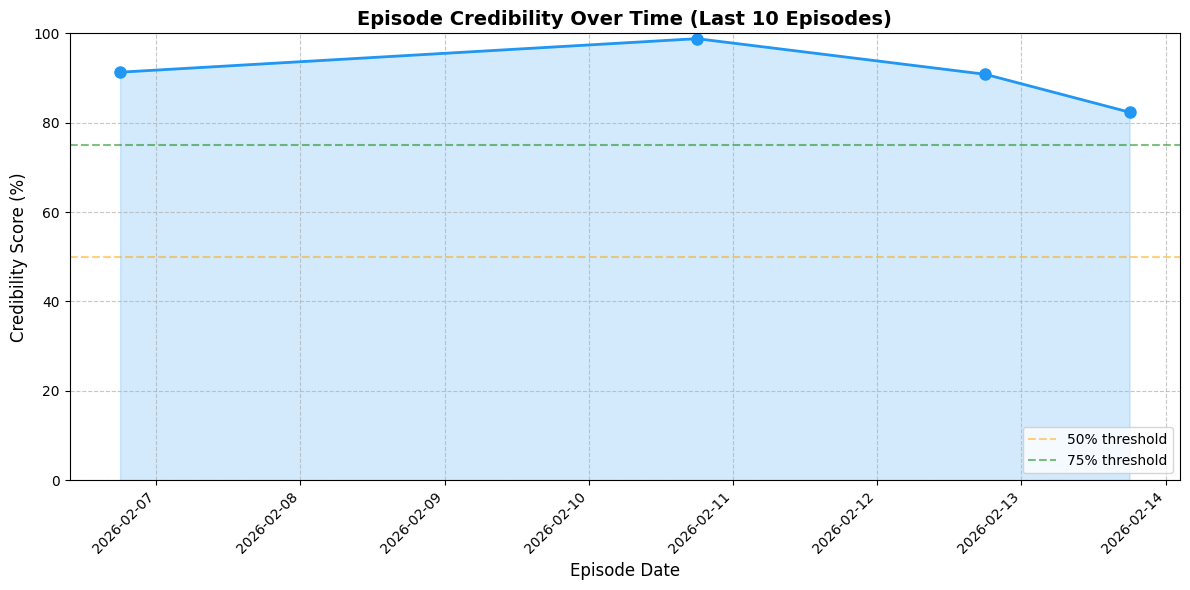

In [7]:
if len(dates) < 2:
    print("Not enough data points to plot. Need at least 2 episodes with valid scores.")
else:
    # Sort by date (oldest to newest) for plotting
    sorted_data = sorted(zip(dates, credibility_scores, episode_titles), key=lambda x: x[0])
    dates_sorted = [d[0] for d in sorted_data]
    scores_sorted = [d[1] for d in sorted_data]

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(dates_sorted, scores_sorted, marker='o', linewidth=2, markersize=8, color='#2196F3')
    ax.fill_between(dates_sorted, scores_sorted, alpha=0.2, color='#2196F3')

    # Configure axes
    ax.set_xlabel('Episode Date', fontsize=12)
    ax.set_ylabel('Credibility Score (%)', fontsize=12)
    ax.set_title('Episode Credibility Over Time (Last 10 Episodes)', fontsize=14, fontweight='bold')

    # Set y-axis limits to 0-100%
    ax.set_ylim(0, 100)

    # Format x-axis dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.xticks(rotation=45, ha='right')

    # Add grid
    ax.grid(True, linestyle='--', alpha=0.7)

    # Add horizontal reference lines
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
    ax.axhline(y=75, color='green', linestyle='--', alpha=0.5, label='75% threshold')

    ax.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

## Summary Statistics

In [8]:
import statistics

valid_scores = [s for s in credibility_scores if s is not None]

if len(valid_scores) >= 2:
    print("Summary Statistics for Episode Credibility")
    print("=" * 45)
    print(f"Number of episodes analyzed: {len(valid_scores)}")
    print(f"Average credibility:         {statistics.mean(valid_scores):.1f}%")
    print(f"Median credibility:          {statistics.median(valid_scores):.1f}%")
    print(f"Standard deviation:          {statistics.stdev(valid_scores):.1f}%")
    print(f"Minimum credibility:         {min(valid_scores):.1f}%")
    print(f"Maximum credibility:         {max(valid_scores):.1f}%")
elif len(valid_scores) == 1:
    print(f"Only 1 episode analyzed with credibility: {valid_scores[0]:.1f}%")
else:
    print("No valid scores to compute statistics.")

Summary Statistics for Episode Credibility
Number of episodes analyzed: 4
Average credibility:         90.8%
Median credibility:          91.1%
Standard deviation:          6.7%
Minimum credibility:         82.4%
Maximum credibility:         98.8%
